# HW8 Exploration Methods — Structured Workflow

This notebook implements the required exploration baselines for HW8 and follows the mandated structure: overview → setup/config → data → model/policies → training → evaluation → visualization → run metadata logging. Run cells top-down after creating a virtual environment and installing `requirements.txt` in this folder.


In [1]:
"""Setup and configuration: imports, seeds, hyperparameters."""

from __future__ import annotations

import json
import os
import platform
import random
import subprocess
from dataclasses import asdict, dataclass
from typing import Dict, List, Tuple

import numpy as np
import torch


def set_seed(seed: int) -> None:
    """Seed random number generators for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


@dataclass
class BanditConfig:
    num_arms: int = 10
    horizon: int = 5000
    epsilon: float = 0.1
    ucb_c: float = 2.0
    alpha0: float = 1.0
    beta0: float = 1.0
    seed: int = 7
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


config = BanditConfig()
set_seed(config.seed)
DEVICE = torch.device(config.device)
print(f"Using device: {DEVICE}")

Using device: cpu


In [2]:
"""Bandit environment definition (Bernoulli arms) and helpers."""

@dataclass
class BernoulliBandit:
    means: np.ndarray

    @classmethod
    def random(
        cls, num_arms: int, seed: int, low: float = 0.05, high: float = 0.95
    ) -> "BernoulliBandit":
        rng = np.random.default_rng(seed)
        means = rng.uniform(low=low, high=high, size=num_arms)
        return cls(means=means)

    def pull(self, arm: int, rng: np.random.Generator) -> float:
        assert 0 <= arm < self.means.shape[0], "arm index out of range"
        return float(rng.random() < self.means[arm])

    @property
    def best_mean(self) -> float:
        return float(self.means.max())


def regret_curve(rewards: np.ndarray, optimal_mean: float) -> np.ndarray:
    """Compute cumulative regret given rewards and optimal arm mean."""
    timesteps = rewards.shape[0]
    optimal_returns = np.full(shape=timesteps, fill_value=optimal_mean)
    inst_regret = optimal_returns - rewards
    return np.cumsum(inst_regret)

In [3]:
"""Exploration policies: epsilon-greedy, UCB1, Thompson sampling (Beta-Bernoulli)."""


class BasePolicy:
    def select(self, t: int) -> int:  # pragma: no cover - interface
        raise NotImplementedError

    def update(self, arm: int, reward: float) -> None:  # pragma: no cover - interface
        raise NotImplementedError


class EpsilonGreedy(BasePolicy):
    def __init__(self, num_arms: int, epsilon: float, seed: int) -> None:
        self.num_arms = num_arms
        self.epsilon = epsilon
        self.rng = np.random.default_rng(seed)
        self.counts = np.zeros(num_arms, dtype=np.int64)
        self.values = np.zeros(num_arms, dtype=np.float64)

    def select(self, t: int) -> int:
        explore = self.rng.random() < self.epsilon
        if explore:
            return int(self.rng.integers(low=0, high=self.num_arms))
        return int(np.argmax(self.values))

    def update(self, arm: int, reward: float) -> None:
        self.counts[arm] += 1
        n = self.counts[arm]
        self.values[arm] += (reward - self.values[arm]) / n


class UCB1(BasePolicy):
    def __init__(self, num_arms: int, c: float, seed: int) -> None:
        self.num_arms = num_arms
        self.c = c
        self.rng = np.random.default_rng(seed)
        self.counts = np.zeros(num_arms, dtype=np.int64)
        self.values = np.zeros(num_arms, dtype=np.float64)

    def select(self, t: int) -> int:
        # pull each arm at least once
        for arm in range(self.num_arms):
            if self.counts[arm] == 0:
                return arm
        confidence = self.c * np.sqrt(np.log(max(t, 1)) / self.counts)
        return int(np.argmax(self.values + confidence))

    def update(self, arm: int, reward: float) -> None:
        self.counts[arm] += 1
        n = self.counts[arm]
        self.values[arm] += (reward - self.values[arm]) / n


class ThompsonBeta(BasePolicy):
    def __init__(self, num_arms: int, alpha0: float, beta0: float, seed: int) -> None:
        self.num_arms = num_arms
        self.rng = np.random.default_rng(seed)
        self.alpha = np.full(num_arms, fill_value=alpha0, dtype=np.float64)
        self.beta = np.full(num_arms, fill_value=beta0, dtype=np.float64)

    def select(self, t: int) -> int:
        samples = self.rng.beta(self.alpha, self.beta)
        return int(np.argmax(samples))

    def update(self, arm: int, reward: float) -> None:
        self.alpha[arm] += reward
        self.beta[arm] += 1.0 - reward

In [4]:
"""Training/evaluation loops for each exploration strategy."""

PolicyResult = Tuple[np.ndarray, np.ndarray]


def run_policy(
    env: BernoulliBandit,
    policy: BasePolicy,
    horizon: int,
    seed: int,
) -> PolicyResult:
    rewards = np.zeros(horizon, dtype=np.float64)
    rng = np.random.default_rng(seed)
    for t in range(horizon):
        arm = policy.select(t + 1)
        reward = env.pull(arm, rng)
        policy.update(arm, reward)
        rewards[t] = reward
    regrets = regret_curve(rewards=rewards, optimal_mean=env.best_mean)
    return rewards, regrets


def evaluate_policies(
    env: BernoulliBandit, cfg: BanditConfig
) -> Dict[str, PolicyResult]:
    policies: Dict[str, BasePolicy] = {
        "epsilon_greedy": EpsilonGreedy(
            num_arms=cfg.num_arms, epsilon=cfg.epsilon, seed=cfg.seed + 1
        ),
        "ucb1": UCB1(num_arms=cfg.num_arms, c=cfg.ucb_c, seed=cfg.seed + 2),
        "thompson_beta": ThompsonBeta(
            num_arms=cfg.num_arms, alpha0=cfg.alpha0, beta0=cfg.beta0, seed=cfg.seed + 3
        ),
    }
    outputs: Dict[str, PolicyResult] = {}
    for name, policy in policies.items():
        outputs[name] = run_policy(
            env=env, policy=policy, horizon=cfg.horizon, seed=cfg.seed
        )
    return outputs

## Training and evaluation

Execute the cell below to instantiate a Bernoulli bandit, run each exploration policy for the configured horizon, and collect rewards/regret curves. Keep horizons modest for smoke testing before any long runs.


In [5]:
"""Run all policies for the configured horizon and aggregate results."""

env = BernoulliBandit.random(num_arms=config.num_arms, seed=config.seed)
results = evaluate_policies(env=env, cfg=config)

summary = {
    name: {
        "mean_reward": float(vals[0].mean()),
        "final_regret": float(vals[1][-1]),
    }
    for name, vals in results.items()
}
summary

{'epsilon_greedy': {'mean_reward': 0.8248, 'final_regret': 163.46210436310696},
 'ucb1': {'mean_reward': 0.7734, 'final_regret': 420.4621043631441},
 'thompson_beta': {'mean_reward': 0.8434, 'final_regret': 70.4621043630868}}

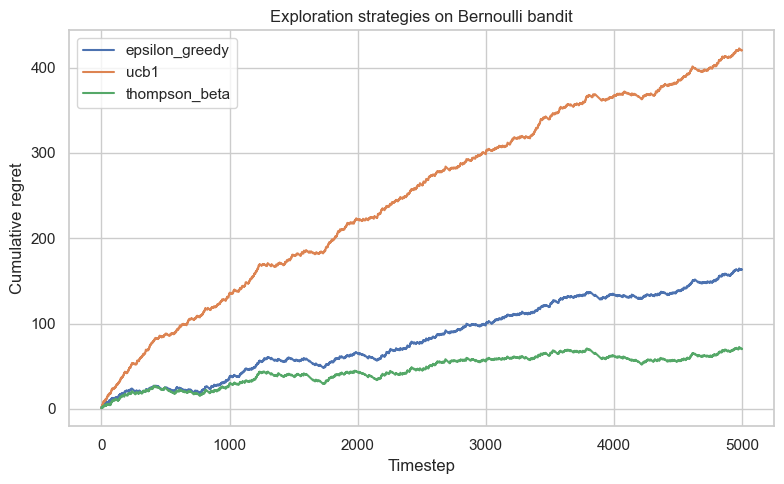

In [6]:
"""Visualization helpers for regret curves."""

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


def plot_regret(results: Dict[str, PolicyResult]) -> None:
    output_dir = os.path.abspath(os.path.join(os.getcwd(), "../pictures"))
    os.makedirs(output_dir, exist_ok=True)
    plt.figure(figsize=(8, 5))
    for name, (_, regret) in results.items():
        plt.plot(regret, label=name)
    plt.xlabel("Timestep")
    plt.ylabel("Cumulative regret")
    plt.title("Exploration strategies on Bernoulli bandit")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "hw8_regret.png"), dpi=300)


plot_regret(results)

In [7]:
"""Persist run metadata for reproducibility (commit hash, hardware, hyperparameters)."""


def git_commit_hash() -> str:
    try:
        return subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip()
    except Exception as exc:  # noqa: BLE001
        print(f"Could not read git commit: {exc}")
        return "unknown"


def gather_run_info(cfg: BanditConfig) -> Dict[str, object]:
    return {
        "commit": git_commit_hash(),
        "platform": platform.platform(),
        "cuda_available": torch.cuda.is_available(),
        "device": cfg.device,
        "hyperparameters": asdict(cfg),
        "dataset": "Bernoulli multi-armed bandit (synthetic)",
    }


def save_run_info(info: Dict[str, object], path: str = "run_info.json") -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(info, f, indent=2)
    print(f"Saved run metadata to {os.path.abspath(path)}")


run_info = gather_run_info(config)
save_run_info(run_info)
run_info

Saved run metadata to /Users/tahamajs/Documents/uni/DRL/homeworks/HW8_Exploration_Methods/code/run_info.json


{'commit': 'ecf9dd458561a60eb72b93133f5f4a6a2e60d0b7',
 'platform': 'macOS-26.1-arm64-arm-64bit-Mach-O',
 'cuda_available': False,
 'device': 'cpu',
 'hyperparameters': {'num_arms': 10,
  'horizon': 5000,
  'epsilon': 0.1,
  'ucb_c': 2.0,
  'alpha0': 1.0,
  'beta0': 1.0,
  'seed': 7,
  'device': 'cpu'},
 'dataset': 'Bernoulli multi-armed bandit (synthetic)'}

In [8]:
"""Run full experiment using the comparison wrapper (external script)."""

import os
import sys
import subprocess

# Output directory for aggregated results and plots
out_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "results"))
os.makedirs(out_dir, exist_ok=True)

script = os.path.abspath(
    os.path.join(os.getcwd(), "..", "bandits", "compare_algorithms.py")
)
cmd = [
    sys.executable,
    script,
    "--num_arms",
    str(config.num_arms),
    "--steps",
    str(config.horizon),
    "--runs",
    "20",
    "--out_dir",
    out_dir,
]

print("Running:", " ".join(cmd))
try:
    subprocess.check_call(cmd)
except subprocess.CalledProcessError as e:
    print("Experiment failed:", e)

Running: /Users/tahamajs/Documents/uni/DRL/.venv/bin/python /Users/tahamajs/Documents/uni/DRL/homeworks/HW8_Exploration_Methods/bandits/compare_algorithms.py --num_arms 10 --steps 5000 --runs 20 --out_dir /Users/tahamajs/Documents/uni/DRL/homeworks/HW8_Exploration_Methods/results
Saved results to /Users/tahamajs/Documents/uni/DRL/homeworks/HW8_Exploration_Methods/results/bandit_results.npz
Calling visualization helper...
Saved plots to /Users/tahamajs/Documents/uni/DRL/homeworks/HW8_Exploration_Methods/results
